# Predição do preço do ouro com GRU + CV temporal

Versão com validação cruzada temporal (`TimeSeriesSplit`) equivalente ao `gold_price_xgboost_cv_bayes.ipynb`.

Mantém:
- `gold_features.csv`
- horizontes `[5, 15, 30]`
- `TimeSeriesSplit(n_splits=5)` sobre o trainval
- escalonamento independente por fold (evita data leakage)
- modelo final treinado no trainval completo, avaliado no teste
- salvamento de CSVs e figuras em `outputs/03_gru/`

In [6]:
from pathlib import Path

import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Model, callbacks, layers

from src import (
    make_windows,
    per_year_metrics,
    plot_learning_curves,
    plot_predicted_vs_actual,
    plot_price_series,
    plot_return_predictions,
    plot_residuals,
    plot_scatter,
    plot_split_regions,
    plot_yearly_perf,
    regression_metrics,
)
from src import ROOT_DIR

# Configura GPU: habilita memory growth para evitar OOM
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU disponível: {[g.name for g in gpus]}")
else:
    print("Nenhuma GPU encontrada — treinando na CPU.")

REPO_ROOT = ROOT_DIR
SEED = 42
LOOKBACK = 60
HORIZONS = [5, 15, 30]
GAP = max(HORIZONS)
EPOCHS = 120
BATCH_SIZE = 64
CV_SPLITS = 5
N_TRIALS = 20           # iterações da busca bayesiana
TUNER_VAL_SPLIT = 0.15  # fração do trainval usada como val interno do tuner
TRAIN_RATIO = 0.85
SHOW_PLOTS = True

CSV_PATH = REPO_ROOT / "data" / "processed" / "gold_features.csv"
ARTIFACTS_DIR = REPO_ROOT / "outputs" / "03_gru"
TUNER_DIR = ARTIFACTS_DIR / "tuner"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)

print("TensorFlow", tf.__version__)
print("Keras Tuner", kt.__version__)
print("Repo root:", REPO_ROOT)

Nenhuma GPU encontrada — treinando na CPU.
TensorFlow 2.21.0
Keras Tuner 1.4.8
Repo root: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast


## Helpers

In [7]:
def load_processed_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
    return df


def select_feature_cols(df: pd.DataFrame) -> list[str]:
    blocked = {"date", "close", "open", "high", "low"}
    return [
        col
        for col in df.columns
        if col not in blocked
        and not col.startswith("y_")
        and pd.api.types.is_numeric_dtype(df[col])
        and df[col].nunique(dropna=True) > 1
    ]


def scale_fold(
    X_tr: np.ndarray,
    Y_tr: np.ndarray,
    X_va: np.ndarray,
    Y_va: np.ndarray,
) -> tuple:
    """Escala X e Y usando estatísticas do treino do fold."""
    n_tr, lb, n_f = X_tr.shape
    x_sc = StandardScaler()
    X_tr_s = x_sc.fit_transform(X_tr.reshape(-1, n_f)).reshape(n_tr, lb, n_f)
    X_va_s = x_sc.transform(X_va.reshape(-1, n_f)).reshape(-1, lb, n_f)

    y_sc = StandardScaler()
    Y_tr_s = y_sc.fit_transform(Y_tr)
    Y_va_s = y_sc.transform(Y_va)

    return X_tr_s, Y_tr_s, X_va_s, Y_va_s, x_sc, y_sc


def to_y_dict(Y_scaled: np.ndarray, horizons: list[int]) -> dict:
    return {f"h{h}": Y_scaled[:, i] for i, h in enumerate(horizons)}


def inverse_preds(
    raw: list[np.ndarray] | np.ndarray,
    y_scaler: StandardScaler,
) -> np.ndarray:
    if isinstance(raw, list):
        stacked = np.column_stack([p.flatten() for p in raw])
    else:
        stacked = raw
    return y_scaler.inverse_transform(stacked).astype(np.float32)


def build_model_hp(hp: kt.HyperParameters, n_features: int) -> Model:
    """Modelo GRU com search space para o Keras Tuner."""
    units       = hp.Int("units",           min_value=32,  max_value=128, step=32)
    spatial_dr  = hp.Float("spatial_dropout", min_value=0.05, max_value=0.30, step=0.05)
    dense_units = hp.Int("dense_units",     min_value=32,  max_value=128, step=32)
    drop        = hp.Float("dropout",       min_value=0.10, max_value=0.40, step=0.10)
    lr          = hp.Float("lr",            min_value=1e-4, max_value=1e-2, sampling="log")
    w15         = hp.Float("loss_weight_h15", min_value=0.4, max_value=1.0, step=0.2)
    w30         = hp.Float("loss_weight_h30", min_value=0.2, max_value=0.8, step=0.2)

    inp = layers.Input(shape=(LOOKBACK, n_features))
    x = layers.GRU(units, return_sequences=True)(inp)
    x = layers.LayerNormalization()(x)
    x = layers.SpatialDropout1D(spatial_dr)(x)
    x = layers.GRU(units)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outs = [layers.Dense(1, name=f"h{h}")(x) for h in HORIZONS]
    model = Model(inp, outs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss={f"h{h}": tf.keras.losses.Huber(1.0) for h in HORIZONS},
        loss_weights={"h5": 1.0, "h15": w15, "h30": w30},
    )
    return model


def build_model_fixed(best_hp: dict, n_features: int) -> Model:
    """Constrói o modelo com hiperparâmetros fixos (pós-busca)."""
    inp = layers.Input(shape=(LOOKBACK, n_features))
    x = layers.GRU(best_hp["units"], return_sequences=True)(inp)
    x = layers.LayerNormalization()(x)
    x = layers.SpatialDropout1D(best_hp["spatial_dropout"])(x)
    x = layers.GRU(best_hp["units"])(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(best_hp["dense_units"], activation="relu")(x)
    x = layers.Dropout(best_hp["dropout"])(x)
    outs = [layers.Dense(1, name=f"h{h}")(x) for h in HORIZONS]
    model = Model(inp, outs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(best_hp["lr"]),
        loss={f"h{h}": tf.keras.losses.Huber(1.0) for h in HORIZONS},
        loss_weights={
            "h5": 1.0,
            "h15": best_hp["loss_weight_h15"],
            "h30": best_hp["loss_weight_h30"],
        },
    )
    return model


def show_or_close(fig: plt.Figure) -> None:
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

## Carregamento

In [8]:
df = load_processed_data(CSV_PATH)
feature_cols = select_feature_cols(df)

print(f"{len(df)} linhas | {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"{len(feature_cols)} features:")
print(feature_cols)

6177 linhas | 2000-08-30 -> 2025-04-14
19 features:
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']


## Série histórica e splits

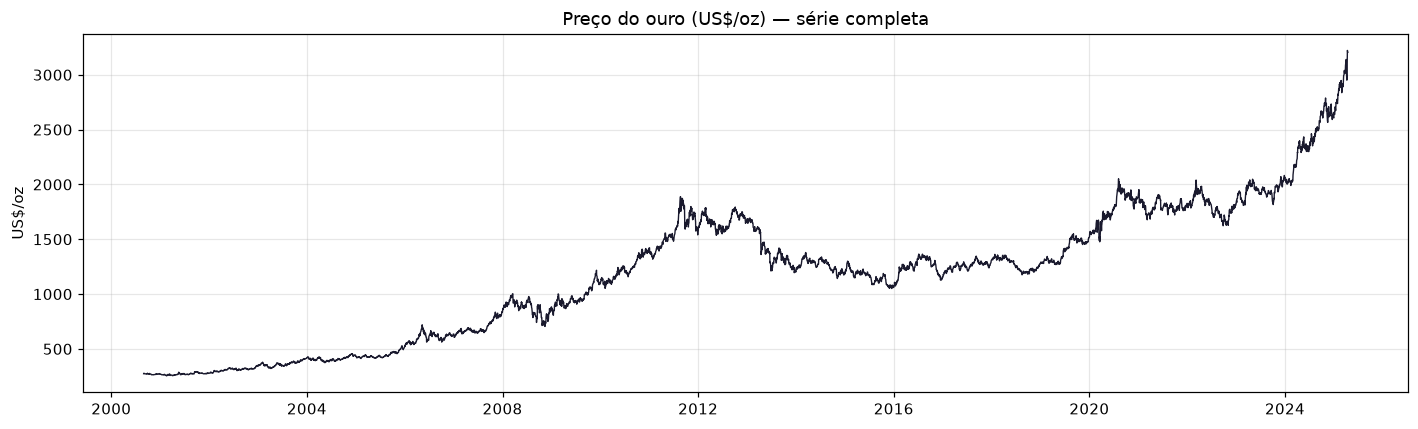

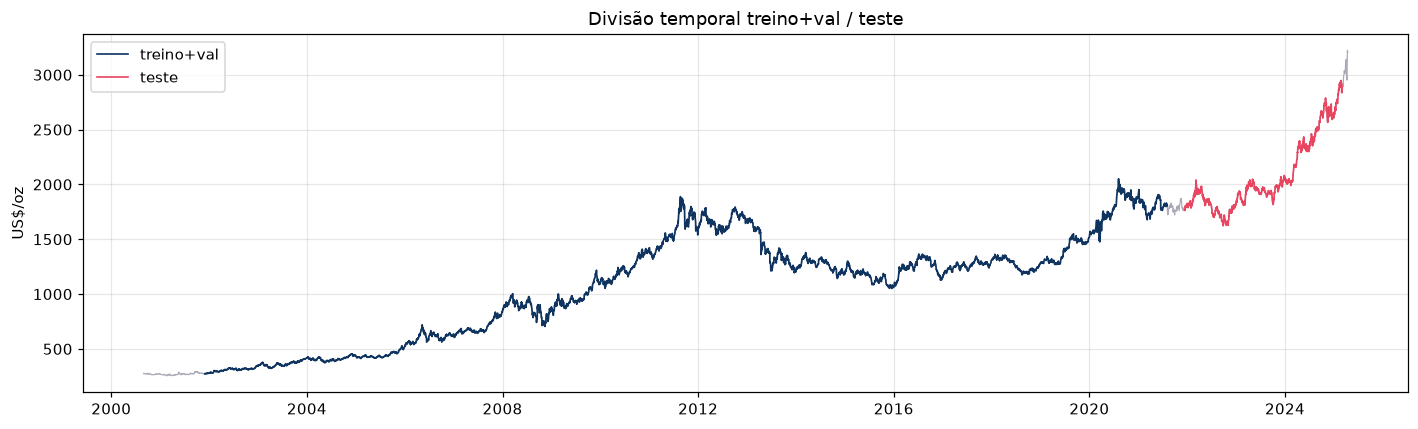

trainval: (4940, 60, 19) | 2001-11-29 -> 2021-08-05
   teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


In [9]:
fig = plot_price_series(
    df["date"],
    df["close"],
    title="Preço do ouro (US$/oz) — série completa",
    ylabel="US$/oz",
)
fig.savefig(ARTIFACTS_DIR / "price_series.png", bbox_inches="tight")
show_or_close(fig)

# Trainval / test split sem gap entre eles (gap só entre folds internos do CV)
n = len(df)
trainval_end = int(n * TRAIN_RATIO)
margin = GAP + LOOKBACK

trainval_ws = make_windows(df, feature_cols, HORIZONS, LOOKBACK, 0, trainval_end)
test_ws = make_windows(
    df, feature_cols, HORIZONS, LOOKBACK, trainval_end + margin, n
)

viz_splits = {
    "treino+val": (trainval_ws.X, trainval_ws.Y, trainval_ws.prices, trainval_ws.idx),
    "teste": (test_ws.X, test_ws.Y, test_ws.prices, test_ws.idx),
}
fig = plot_split_regions(
    df,
    viz_splits,
    title="Divisão temporal treino+val / teste",
    ylabel="US$/oz",
    split_colors={"treino+val": "#0f3460", "teste": "#e94560"},
)
fig.savefig(ARTIFACTS_DIR / "split_regions.png", bbox_inches="tight")
show_or_close(fig)

print(
    f"trainval: {trainval_ws.X.shape} | "
    f"{df['date'].iloc[trainval_ws.idx[0]].date()} -> "
    f"{df['date'].iloc[trainval_ws.idx[-1]].date()}"
)
print(
    f"   teste: {test_ws.X.shape} | "
    f"{df['date'].iloc[test_ws.idx[0]].date()} -> "
    f"{df['date'].iloc[test_ws.idx[-1]].date()}"
)

## Busca bayesiana de hiperparâmetros (Keras Tuner)

`BayesianOptimization` explora o search space abaixo com `N_TRIALS` iterações.
O tuner usa os últimos `TUNER_VAL_SPLIT` % do trainval como validação interna.

| Hiperparâmetro | Range |
|---|---|
| `units` (GRU) | 32 – 128 (step 32) |
| `spatial_dropout` | 0.05 – 0.30 (step 0.05) |
| `dense_units` | 32 – 128 (step 32) |
| `dropout` | 0.10 – 0.40 (step 0.10) |
| `lr` | 1e-4 – 1e-2 (log-uniform) |
| `loss_weight_h15` | 0.4 – 1.0 (step 0.2) |
| `loss_weight_h30` | 0.2 – 0.8 (step 0.2) |

In [10]:
# Escala o trainval para o tuner (fit no bloco de treino, transform no bloco de val)
X_tv_all = trainval_ws.X.astype(np.float32)
Y_tv_all = trainval_ws.Y.astype(np.float32)
n_tv_all, lb, n_f = X_tv_all.shape

n_tuner_train = int(n_tv_all * (1 - TUNER_VAL_SPLIT))
X_tun_tr, Y_tun_tr = X_tv_all[:n_tuner_train], Y_tv_all[:n_tuner_train]
X_tun_va, Y_tun_va = X_tv_all[n_tuner_train:], Y_tv_all[n_tuner_train:]

x_sc_tun = StandardScaler()
X_tun_tr_s = x_sc_tun.fit_transform(X_tun_tr.reshape(-1, n_f)).reshape(-1, lb, n_f)
X_tun_va_s = x_sc_tun.transform(X_tun_va.reshape(-1, n_f)).reshape(-1, lb, n_f)

y_sc_tun = StandardScaler()
Y_tun_tr_s = y_sc_tun.fit_transform(Y_tun_tr)
Y_tun_va_s = y_sc_tun.transform(Y_tun_va)

n_features = len(feature_cols)

tuner = kt.BayesianOptimization(
    hypermodel=lambda hp: build_model_hp(hp, n_features),
    objective="val_loss",
    max_trials=N_TRIALS,
    seed=SEED,
    directory=str(TUNER_DIR),
    project_name="gru_cv_bayes",
    overwrite=True,
)
tuner.search_space_summary()

tuner.search(
    X_tun_tr_s,
    to_y_dict(Y_tun_tr_s, HORIZONS),
    validation_data=(X_tun_va_s, to_y_dict(Y_tun_va_s, HORIZONS)),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
    ],
)

best_hp = tuner.get_best_hyperparameters(1)[0].values
print("\nMelhores hiperparâmetros encontrados:")
for k, v in best_hp.items():
    print(f"  {k}: {v}")

Search space summary
Default search space size: 7
units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
spatial_dropout (Float)
{'default': 0.05, 'conditions': [], 'min_value': 0.05, 'max_value': 0.3, 'step': 0.05, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
loss_weight_h15 (Float)
{'default': 0.4, 'conditions': [], 'min_value': 0.4, 'max_value': 1.0, 'step': 0.2, 'sampling': 'linear'}
loss_weight_h30 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.8, 'step': 0.2, 'sampling': 'linear'}

Melhores hiperparâmetros encontrados:
  units: 64
  spatial_dropout: 0.1

In [11]:
import json

# Top-5 trials
top_trials = tuner.oracle.get_best_trials(5)
trials_rows = []
for trial in top_trials:
    row = {"val_loss": round(trial.score, 6)}
    row.update(trial.hyperparameters.values)
    trials_rows.append(row)
trials_df = pd.DataFrame(trials_rows)
trials_df.to_csv(ARTIFACTS_DIR / "tuner_top5_trials.csv", index=False)

with open(ARTIFACTS_DIR / "best_hp.json", "w") as f:
    json.dump(best_hp, f, indent=2)

print("Top-5 trials:")
trials_df

Top-5 trials:


,val_loss,units,spatial_dropout,dense_units,dropout,lr,loss_weight_h15,loss_weight_h30
0,0.503461,64,0.15,96,0.3,0.000140,0.4,0.2
1,0.510363,96,0.05,96,0.1,0.000108,0.4,0.2
2,0.530602,32,0.15,64,0.3,0.002336,0.6,0.2
3,0.541889,96,0.05,128,0.1,0.000624,0.4,0.2
4,0.547092,128,0.25,32,0.2,0.001028,0.4,0.4


## Validação cruzada temporal (TimeSeriesSplit) com melhores HPs

Para cada fold:
1. Escalonamento de X e Y **apenas** com estatísticas do treino do fold (sem data leakage).
2. Treino do GRU com os hiperparâmetros encontrados pelo tuner + EarlyStopping.
3. Predição e inversão da escala para espaço de log-retorno real.
4. Cálculo de métricas no val do fold.

In [12]:
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
cv_metrics_list = []
fold_histories = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(trainval_ws.X)):
    print(f"\n=== Fold {fold + 1}/{CV_SPLITS} ===")
    print(f"  treino: {len(tr_idx)} amostras | val: {len(va_idx)} amostras")

    X_tr = trainval_ws.X[tr_idx].astype(np.float32)
    Y_tr = trainval_ws.Y[tr_idx].astype(np.float32)
    X_va = trainval_ws.X[va_idx].astype(np.float32)
    Y_va = trainval_ws.Y[va_idx].astype(np.float32)
    P_va = trainval_ws.prices[va_idx]

    X_tr_s, Y_tr_s, X_va_s, Y_va_s, x_sc, y_sc = scale_fold(X_tr, Y_tr, X_va, Y_va)

    tf.random.set_seed(SEED + fold)
    model_fold = build_model_fixed(best_hp, n_features)

    hist = model_fold.fit(
        X_tr_s,
        to_y_dict(Y_tr_s, HORIZONS),
        validation_data=(X_va_s, to_y_dict(Y_va_s, HORIZONS)),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_loss", patience=15, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5
            ),
        ],
    )
    fold_histories.append(hist.history)
    print(f"  épocas treinadas: {len(hist.history['loss'])}")

    raw = model_fold.predict(X_va_s, verbose=0)
    pred_va = inverse_preds(raw, y_sc)

    metrics = regression_metrics(
        Y_va, pred_va, P_va, HORIZONS, split_name=f"fold_{fold + 1}"
    )
    cv_metrics_list.append(metrics)
    print(metrics.round(3).to_string(index=False))

print("\nCV concluído.")


=== Fold 1/5 ===
  treino: 825 amostras | val: 823 amostras
  épocas treinadas: 23
 split  h    MAE   RMSE  MAPE%  DirAcc%  MAE/naive
fold_1  5 14.951 20.099  2.220   53.584      1.022
fold_1 15 26.154 34.359  3.889   56.987      1.019
fold_1 30 34.811 45.369  5.102   66.221      0.954

=== Fold 2/5 ===
  treino: 1648 amostras | val: 823 amostras
  épocas treinadas: 35
 split  h    MAE   RMSE  MAPE%  DirAcc%  MAE/naive
fold_2  5 27.662 36.775  2.473   53.584      1.011
fold_2 15 45.186 59.073  3.994   63.791      0.970
fold_2 30 55.315 74.146  4.861   75.091      0.828

=== Fold 3/5 ===
  treino: 2471 amostras | val: 823 amostras
  épocas treinadas: 17
 split  h    MAE    RMSE  MAPE%  DirAcc%  MAE/naive
fold_3  5 29.806  41.576  2.071   51.033      1.103
fold_3 15 54.709  69.411  3.822   50.790      1.152
fold_3 30 89.756 111.908  6.198   46.051      1.422

=== Fold 4/5 ===
  treino: 3294 amostras | val: 823 amostras
  épocas treinadas: 27
 split  h    MAE   RMSE  MAPE%  DirAcc%  MAE/

## Resumo dos folds

In [13]:
cv_all = pd.concat(cv_metrics_list, ignore_index=True)
cv_all.to_csv(ARTIFACTS_DIR / "cv_metrics_per_fold.csv", index=False)

cv_summary = (
    cv_all.groupby("h")[["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]]
    .agg(["mean", "std"])
    .round(3)
)
cv_summary.to_csv(ARTIFACTS_DIR / "cv_summary.csv")
print("Métricas CV (média ± desvio-padrão entre folds):")
cv_summary

Métricas CV (média ± desvio-padrão entre folds):


MAE            RMSE          MAPE%        DirAcc%         MAE/naive  \
      mean     std    mean     std   mean    std    mean     std      mean   
h                                                                            
5   23.515   6.054  32.062   9.132  1.991  0.389   51.47   2.027     1.042   
15  40.634  10.816  52.880  13.913  3.436  0.644   53.90   6.564     1.047   
30  57.873  20.326  74.114  24.447  4.789  0.963   58.08  12.110     1.074   

           
      std  
h          
5   0.038  
15  0.067  
30  0.225

In [14]:
# Tabela legível: mean (std)
metrics_cols = ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
rows = []
for h in HORIZONS:
    sub = cv_all[cv_all["h"] == h]
    row = {"h": h}
    for col in metrics_cols:
        m, s = sub[col].mean(), sub[col].std()
        row[col] = f"{m:.3f} ± {s:.3f}"
    rows.append(row)
print("\nResumo CV:")
pd.DataFrame(rows).set_index("h")


Resumo CV:


,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
h,,,,,
5,23.515 ± 6.054,32.062 ± 9.132,1.991 ± 0.389,51.470 ± 2.027,1.042 ± 0.038
15,40.634 ± 10.816,52.880 ± 13.913,3.436 ± 0.644,53.900 ± 6.564,1.047 ± 0.067
30,57.873 ± 20.326,74.114 ± 24.447,4.789 ± 0.963,58.080 ± 12.110,1.074 ± 0.225


## Curvas de aprendizado por fold

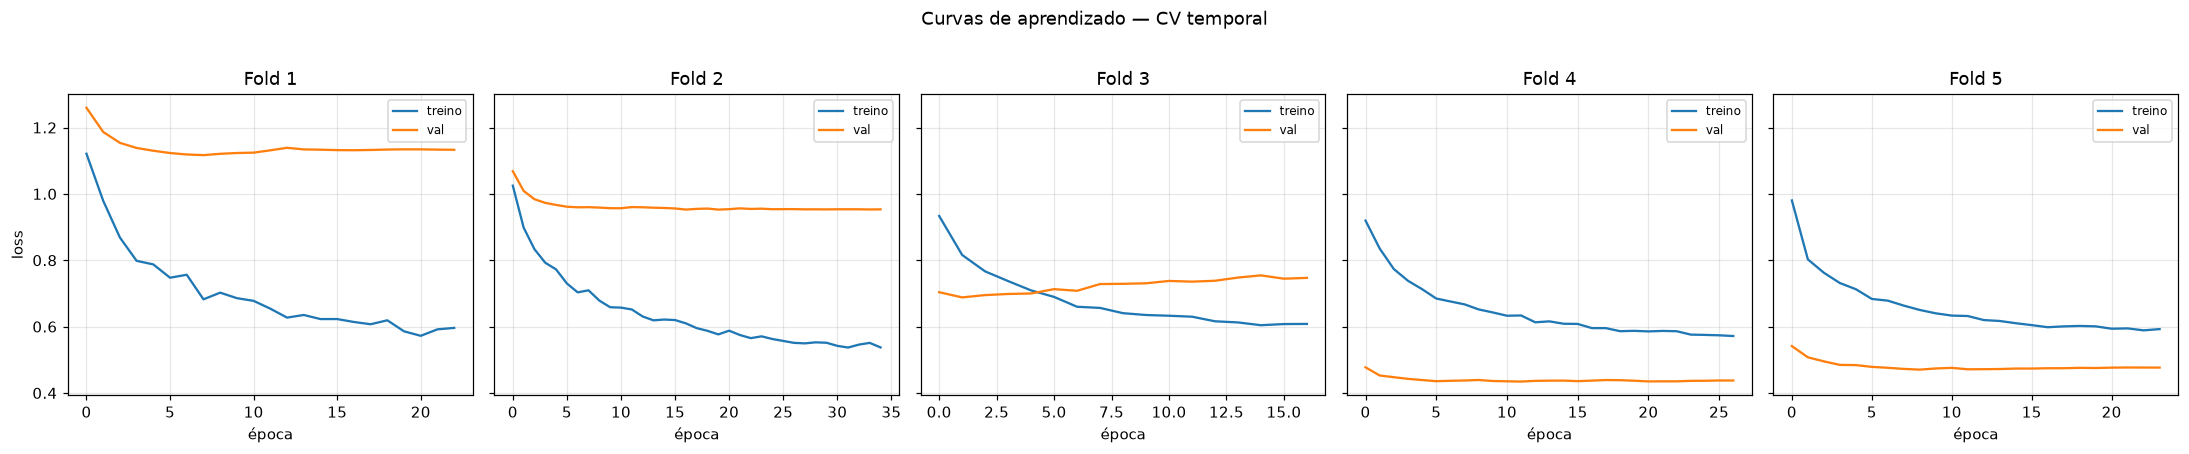

In [15]:
fig, axes = plt.subplots(1, CV_SPLITS, figsize=(4 * CV_SPLITS, 4), sharey=True)
for fold, (ax, hist) in enumerate(zip(axes, fold_histories)):
    ax.plot(hist["loss"], label="treino", lw=1.5)
    ax.plot(hist["val_loss"], label="val", lw=1.5)
    ax.set_title(f"Fold {fold + 1}")
    ax.set_xlabel("época")
    if fold == 0:
        ax.set_ylabel("loss")
    ax.legend(fontsize=8)
plt.suptitle("Curvas de aprendizado — CV temporal", y=1.02)
plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "cv_learning_curves.png", bbox_inches="tight")
show_or_close(fig)

## Distribuição de métricas entre folds

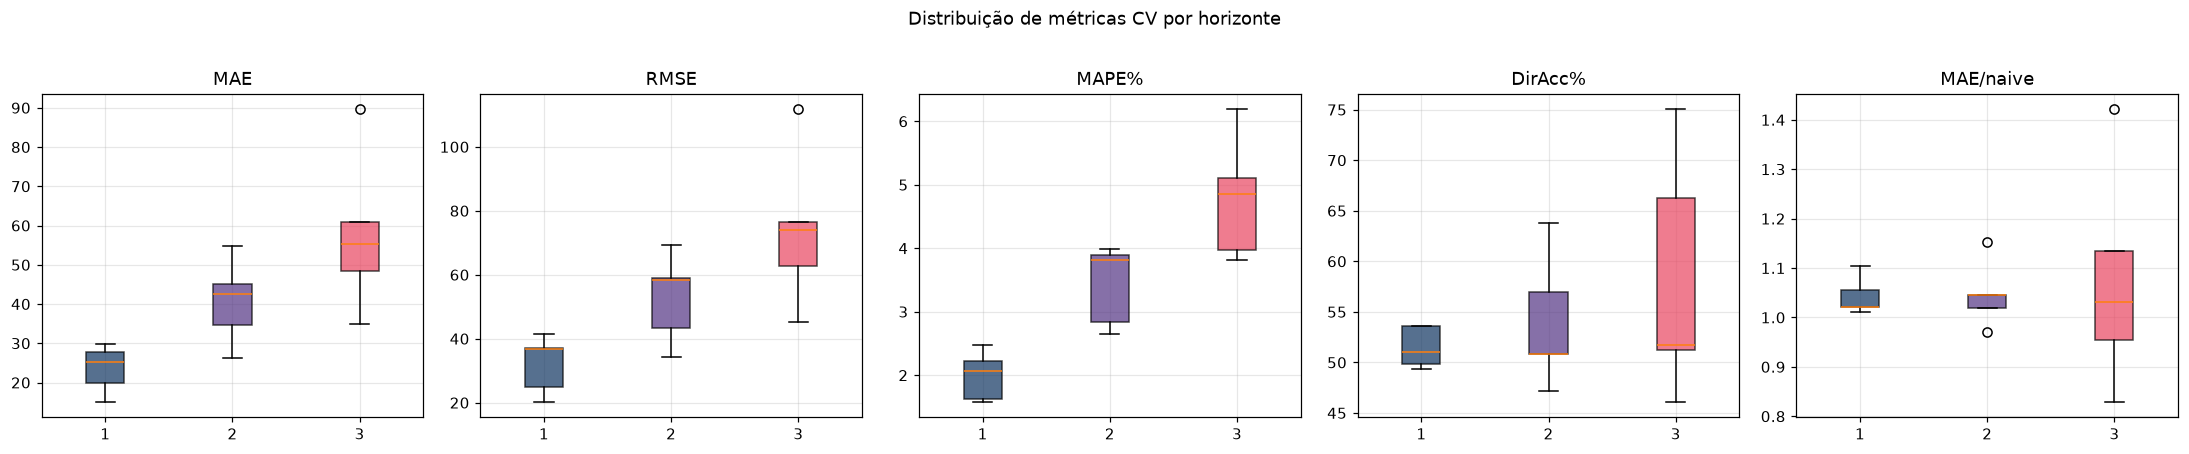

In [17]:
fig, axes = plt.subplots(1, len(metrics_cols), figsize=(4 * len(metrics_cols), 4))
for ax, col in zip(axes, metrics_cols):
    data_by_h = [cv_all[cv_all["h"] == h][col].values for h in HORIZONS]
    bp = ax.boxplot(data_by_h, label=[f"h={h}" for h in HORIZONS], patch_artist=True)
    colors = ["#0f3460", "#533483", "#e94560"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col)
plt.suptitle("Distribuição de métricas CV por horizonte", y=1.02)
plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "cv_metrics_boxplot.png", bbox_inches="tight")
show_or_close(fig)

## Modelo final: treino no trainval completo

Com a arquitetura validada via CV, treina o modelo final no trainval inteiro e avalia no conjunto de teste.

In [18]:
# X_tv_all e Y_tv_all já foram criados na célula do tuner
X_test = test_ws.X.astype(np.float32)
Y_test = test_ws.Y.astype(np.float32)
P_test = test_ws.prices
dates_test = df["date"].values[test_ws.idx]

n_tv, lb, n_f = X_tv_all.shape
x_scaler_final = StandardScaler()
X_tv_s = x_scaler_final.fit_transform(X_tv_all.reshape(-1, n_f)).reshape(n_tv, lb, n_f)
X_te_s = x_scaler_final.transform(X_test.reshape(-1, n_f)).reshape(-1, lb, n_f)

y_scaler_final = StandardScaler()
Y_tv_s = y_scaler_final.fit_transform(Y_tv_all)

print("X_trainval scaled:", X_tv_s.shape)
print("X_test scaled:", X_te_s.shape)

X_trainval scaled: (4940, 60, 19)
X_test scaled: (807, 60, 19)


In [19]:
tf.random.set_seed(SEED)
model_final = build_model_fixed(best_hp, n_features)
model_final.summary()

# Usa os últimos TUNER_VAL_SPLIT do trainval como val interno para EarlyStopping
n_tv_train = int(n_tv * (1 - TUNER_VAL_SPLIT))

history_final = model_final.fit(
    X_tv_s[:n_tv_train],
    to_y_dict(Y_tv_s[:n_tv_train], HORIZONS),
    validation_data=(
        X_tv_s[n_tv_train:],
        to_y_dict(Y_tv_s[n_tv_train:], HORIZONS),
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss", patience=15, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5
        ),
    ],
)
print(f"Treinou {len(history_final.history['loss'])} épocas")

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 60, 19)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_12 (GRU)        │ (None, 60, 64)    │     16,320 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ gru_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 60, 64)    │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_13 (GRU)        │ (None, 64)        │     24,960 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ gru_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 96)        │      6,240 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 96)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h5 (Dense)          │ (None, 1)         │         97 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h15 (Dense)         │ (None, 1)         │         97 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h30 (Dense)         │ (None, 1)         │         97 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,067 (187.76 KB)

 Trainable params: 48,067 (187.76 KB)

 Non-trainable params: 0 (0.00 B)

Treinou 31 épocas


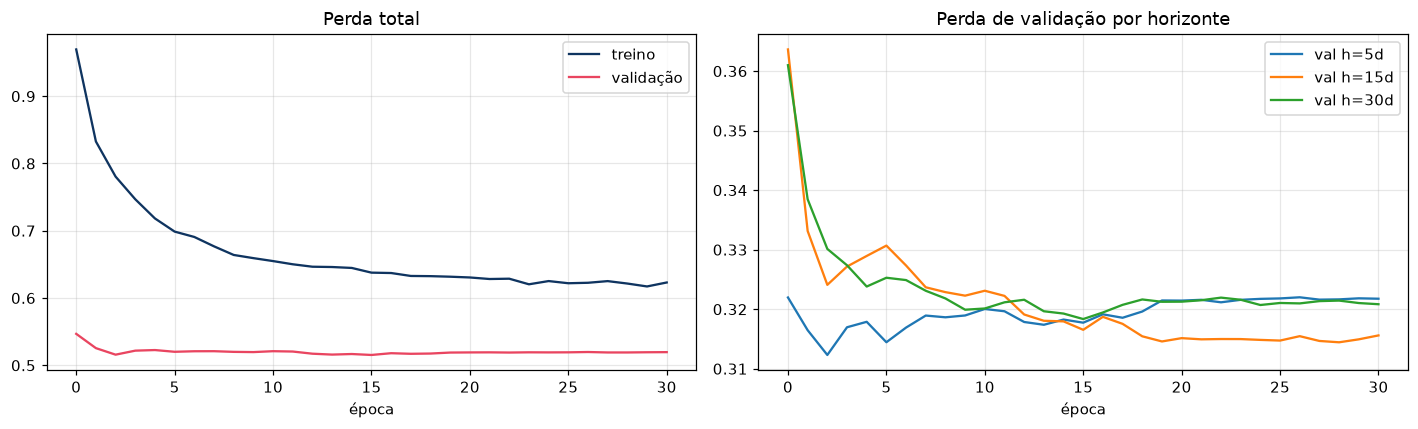

In [20]:
fig = plot_learning_curves(history_final.history, HORIZONS)
fig.savefig(ARTIFACTS_DIR / "learning_curves_final.png", bbox_inches="tight")
show_or_close(fig)

## Avaliação no teste

In [21]:
raw_test = model_final.predict(X_te_s, verbose=0)
pred_test = inverse_preds(raw_test, y_scaler_final)

raw_tv = model_final.predict(X_tv_s, verbose=0)
pred_tv = inverse_preds(raw_tv, y_scaler_final)

tbl = pd.concat(
    [
        regression_metrics(
            Y_tv_all, pred_tv, trainval_ws.prices, HORIZONS, split_name="treino+val"
        ),
        regression_metrics(
            Y_test, pred_test, P_test, HORIZONS, split_name="teste"
        ),
    ],
    ignore_index=True,
)
tbl.to_csv(ARTIFACTS_DIR / "metrics_test.csv", index=False)
tbl.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,treino+val,5,18.637,27.546,1.746,63.219,0.942
1,treino+val,15,31.840,45.567,2.977,62.874,0.937
2,treino+val,30,45.677,63.517,4.210,62.045,0.969
3,teste,5,33.783,42.913,1.625,51.549,1.025
4,teste,15,62.603,78.199,2.968,51.053,1.046
5,teste,30,86.811,108.662,4.049,56.258,0.992


In [22]:
t = tbl[tbl["split"] == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print("DESEMPENHO NO TESTE")
print(t.round(2).to_string())
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   33.78   42.91   1.63    51.55       1.02
15  62.60   78.20   2.97    51.05       1.05
30  86.81  108.66   4.05    56.26       0.99

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## CV vs. teste: comparação de MAE

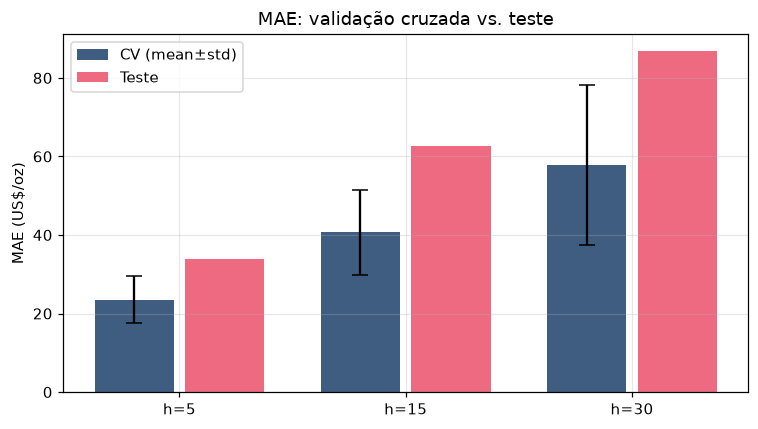

In [23]:
cv_mae = cv_all.groupby("h")["MAE"].agg(["mean", "std"])
test_mae = tbl[tbl["split"] == "teste"].set_index("h")["MAE"]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(HORIZONS))
ax.bar(x - 0.2, cv_mae["mean"], 0.35, yerr=cv_mae["std"], label="CV (mean±std)",
       color="#0f3460", alpha=0.8, capsize=5)
ax.bar(x + 0.2, [test_mae[h] for h in HORIZONS], 0.35, label="Teste",
       color="#e94560", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"h={h}" for h in HORIZONS])
ax.set_ylabel("MAE (US$/oz)")
ax.set_title("MAE: validação cruzada vs. teste")
ax.legend()
plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "cv_vs_test_mae.png", bbox_inches="tight")
show_or_close(fig)

## Gráficos de desempenho no teste

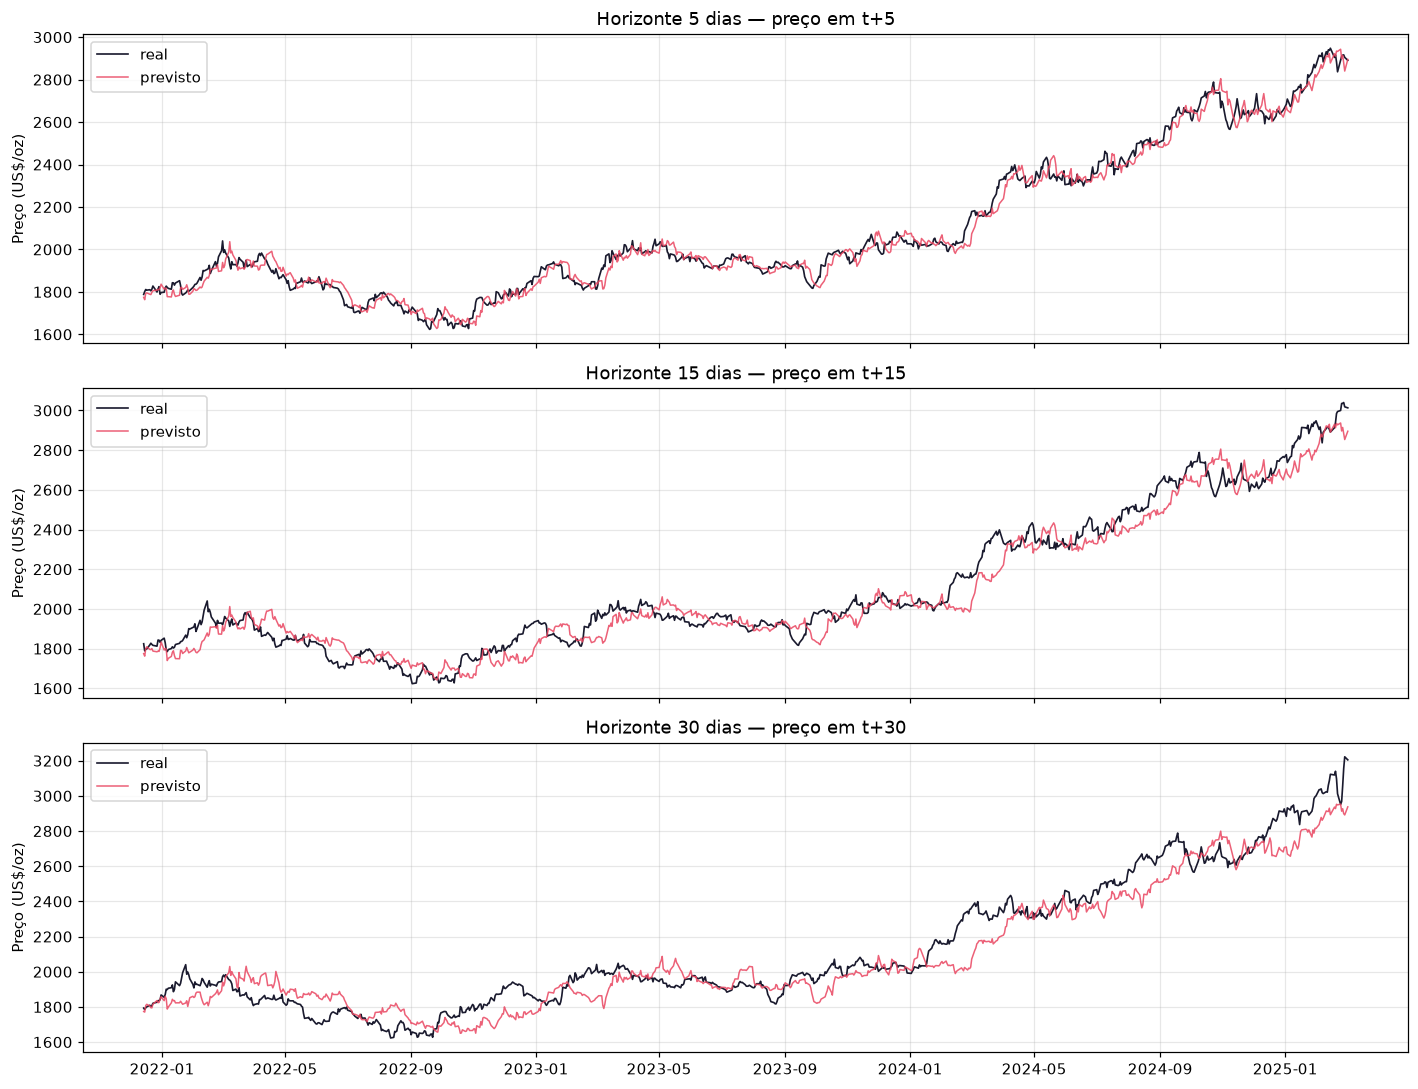

In [24]:
fig = plot_predicted_vs_actual(
    dates_test,
    Y_test,
    pred_test,
    P_test,
    HORIZONS,
    ylabel="Preço (US$/oz)",
)
fig.savefig(ARTIFACTS_DIR / "predicted_vs_actual_test.png", bbox_inches="tight")
show_or_close(fig)

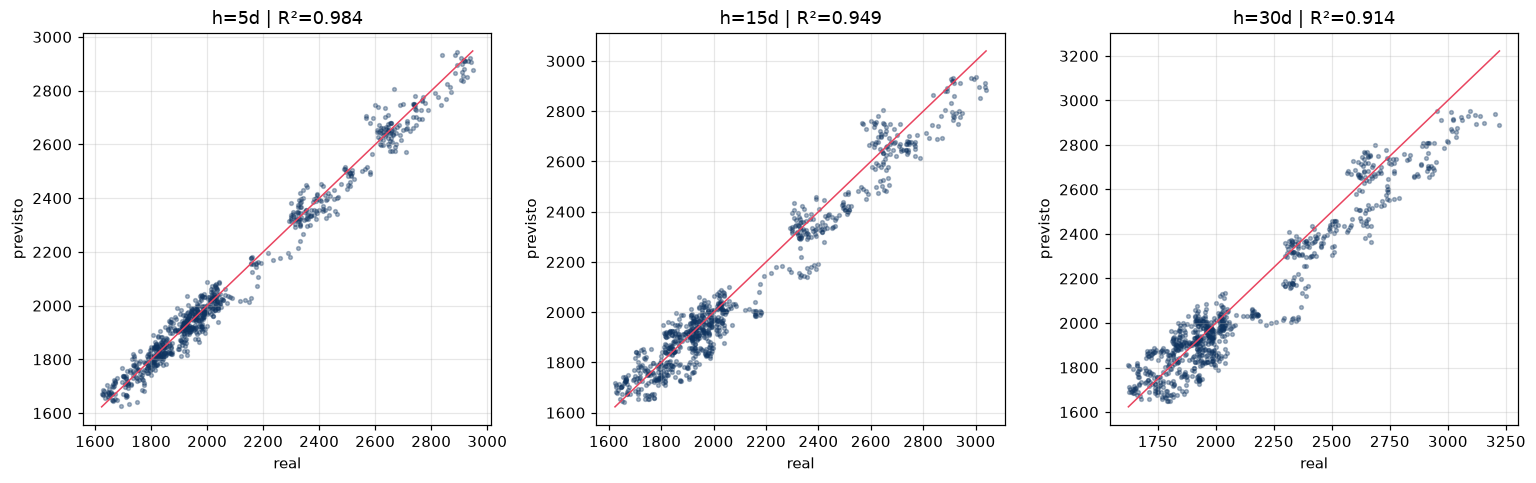

In [25]:
fig = plot_scatter(Y_test, pred_test, P_test, HORIZONS)
fig.savefig(ARTIFACTS_DIR / "scatter_test.png", bbox_inches="tight")
show_or_close(fig)

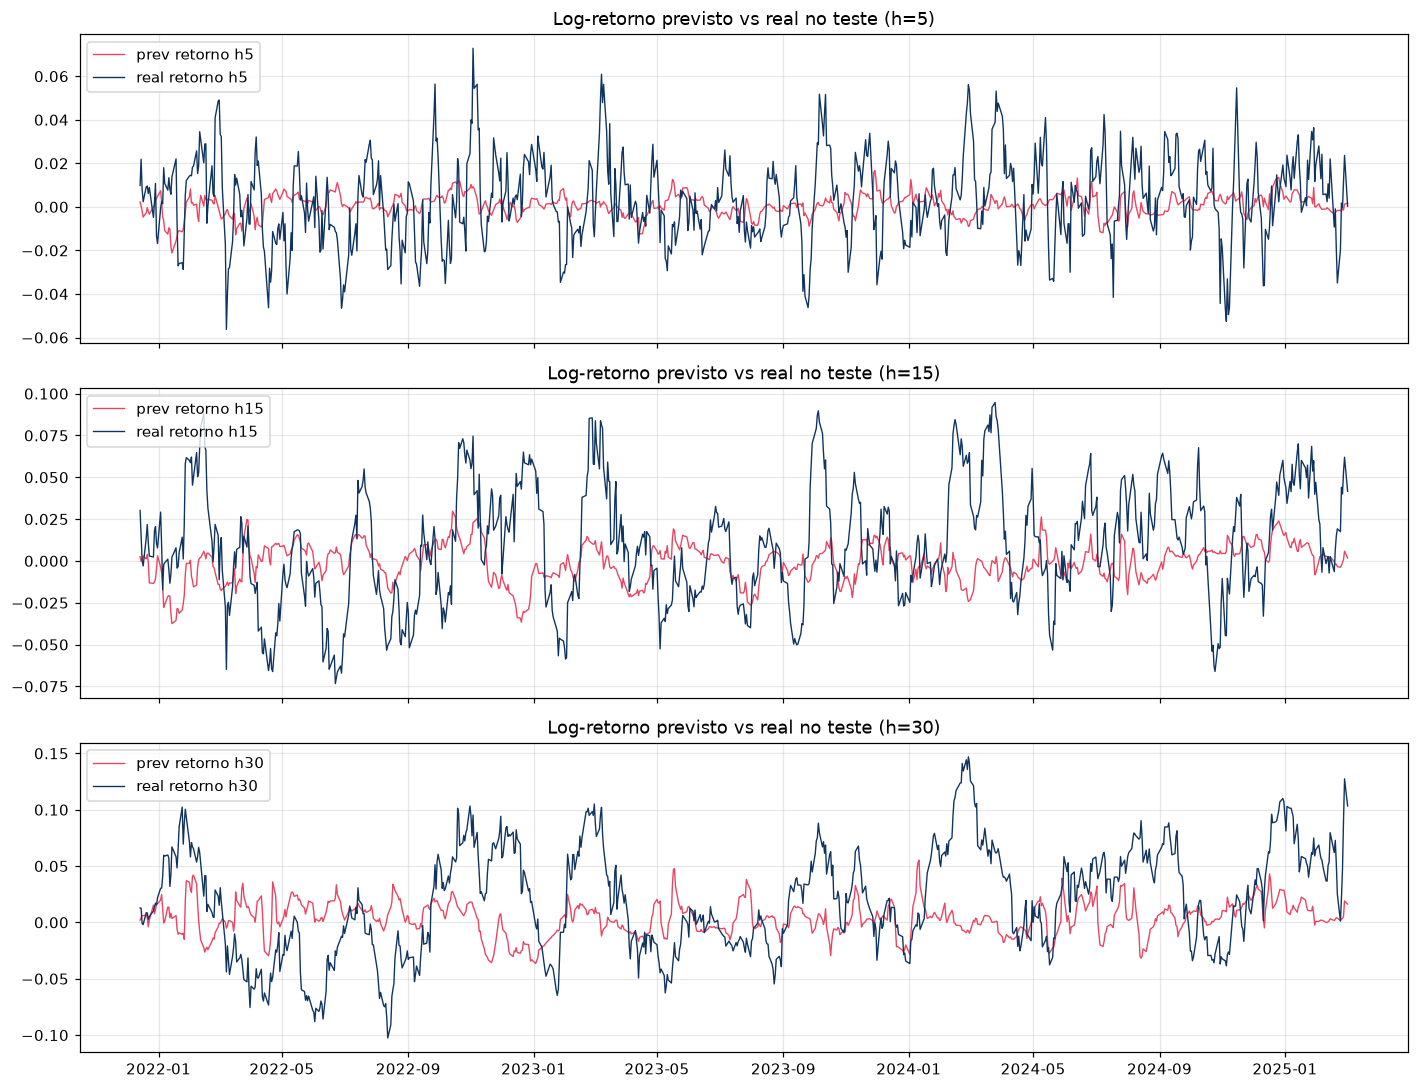

In [26]:
fig = plot_return_predictions(dates_test, Y_test, pred_test, HORIZONS)
fig.savefig(ARTIFACTS_DIR / "returns_test.png", bbox_inches="tight")
show_or_close(fig)

In [27]:
h30_idx = HORIZONS.index(30)
yearly = per_year_metrics(
    Y_test,
    pred_test,
    P_test,
    dates_test,
    horizon_idx=h30_idx,
)
yearly.to_csv(ARTIFACTS_DIR / "yearly_h30.csv")
yearly

,DirAcc%,MAE/naive
ano,,
2021,76.923077,0.560200
2022,38.247012,1.113816
2023,61.600000,0.987789
2024,61.507937,0.941009
2025,95.121951,0.881940


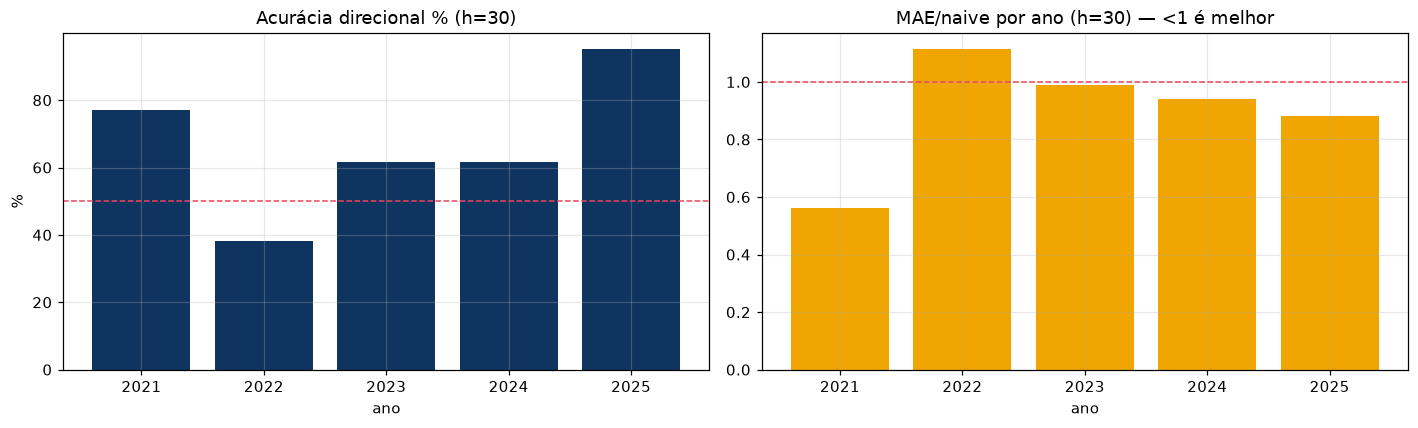

In [28]:
fig = plot_yearly_perf(yearly, horizon=30)
fig.savefig(ARTIFACTS_DIR / "yearly_h30.png", bbox_inches="tight")
show_or_close(fig)

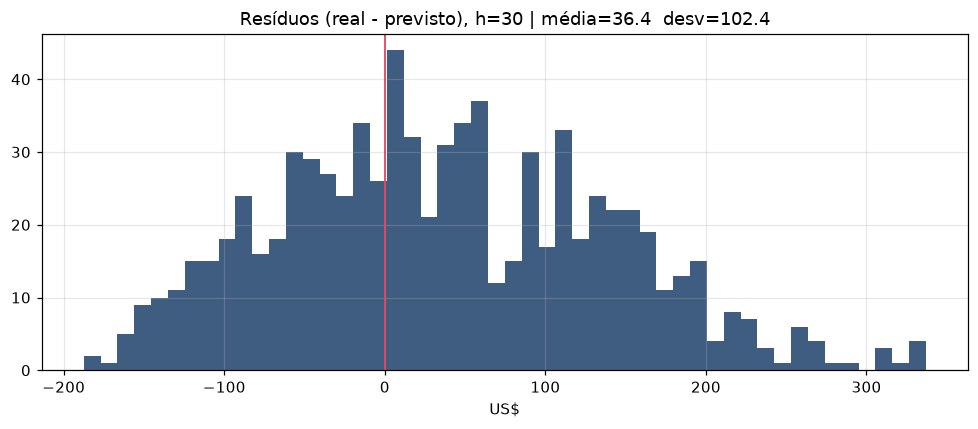

In [29]:
fig = plot_residuals(
    Y_test,
    pred_test,
    P_test,
    horizon_idx=h30_idx,
    horizon=30,
)
fig.savefig(ARTIFACTS_DIR / "residuals_h30.png", bbox_inches="tight")
show_or_close(fig)

In [30]:
print(f"Artefatos salvos em: {ARTIFACTS_DIR}")

Artefatos salvos em: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/03_gru
